In [1]:
# Fix numpy version conflict with Colab's default environment
!pip install numpy==1.26.4 --force-reinstall -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26

In [1]:
# Setup — run this every time you open a new Colab session
import os

if not os.path.exists('/content/tabddpm-hospital-readmission-prediction'):
    !git clone https://github.com/Jiten-Bhalavat/tabddpm-hospital-readmission-prediction.git

os.chdir('/content/tabddpm-hospital-readmission-prediction')
!pip install -r requirements.txt -q

print("Environment setup complete")

Environment setup complete


In [2]:
# Import all required libraries for evaluation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from ctgan import CTGAN

RANDOM_STATE = 42

# Load the processed train/test splits prepared by Rohith
X_train = pd.read_csv('data/processed/X_train.csv')
X_test  = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('data/processed/y_test.csv').squeeze()

print("Data loaded successfully!")
print(f"  X_train shape : {X_train.shape}")
print(f"  X_test shape  : {X_test.shape}")
print(f"  Minority class in train : {(y_train == 1).sum()} patients")
print(f"  Minority class in test  : {(y_test == 1).sum()} patients")

Data loaded successfully!
  X_train shape : (79472, 42)
  X_test shape  : (19868, 42)
  Minority class in train : 9051 patients
  Minority class in test  : 2263 patients


In [3]:
# ── Baseline: Train XGBoost on raw imbalanced data with no augmentation ──
# This is our benchmark. The model will perform poorly on the minority class
# because it has never seen enough readmission examples to learn from.

baseline_model = XGBClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False
)
baseline_model.fit(X_train, y_train)

y_pred_base  = baseline_model.predict(X_test)
y_proba_base = baseline_model.predict_proba(X_test)[:, 1]

f1_base  = f1_score(y_test, y_pred_base, pos_label=1)
auc_base = roc_auc_score(y_test, y_proba_base)
cm_base  = confusion_matrix(y_test, y_pred_base)

print("=" * 50)
print("  BASELINE RESULTS (no augmentation)")
print("=" * 50)
print(f"  F1 Score  (minority class) : {f1_base:.4f}")
print(f"  ROC-AUC                    : {auc_base:.4f}")
print()
print(classification_report(y_test, y_pred_base, target_names=['Not Readmitted', 'Readmitted <30']))

  BASELINE RESULTS (no augmentation)
  F1 Score  (minority class) : 0.0548
  ROC-AUC                    : 0.6581

                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     17605
Readmitted <30       0.45      0.03      0.05      2263

      accuracy                           0.89     19868
     macro avg       0.67      0.51      0.50     19868
  weighted avg       0.84      0.89      0.84     19868



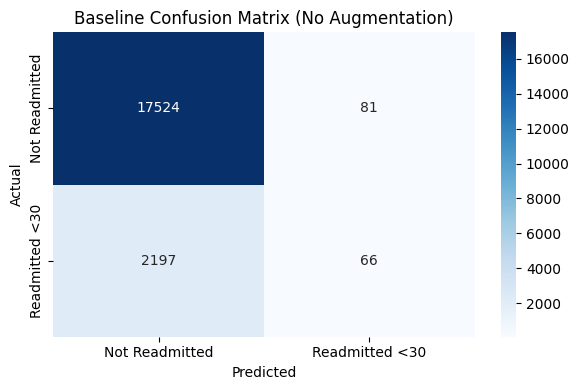

Saved baseline_results.json and baseline_confusion_matrix.png


In [4]:
# Save baseline metrics and confusion matrix plot to results folder

os.makedirs('results/metrics', exist_ok=True)
os.makedirs('results/figures', exist_ok=True)

baseline_metrics = {
    'method'   : 'baseline_no_augmentation',
    'f1_score' : round(f1_base, 4),
    'roc_auc'  : round(auc_base, 4),
    'confusion_matrix': {
        'true_negatives'  : int(cm_base[0][0]),
        'false_positives' : int(cm_base[0][1]),
        'false_negatives' : int(cm_base[1][0]),
        'true_positives'  : int(cm_base[1][1])
    }
}

with open('results/metrics/baseline_results.json', 'w') as f:
    json.dump(baseline_metrics, f, indent=2)

# Confusion matrix plot
plt.figure(figsize=(6, 4))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Readmitted', 'Readmitted <30'],
            yticklabels=['Not Readmitted', 'Readmitted <30'])
plt.title('Baseline Confusion Matrix (No Augmentation)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/figures/baseline_confusion_matrix.png', dpi=150)
plt.show()

print("Saved baseline_results.json and baseline_confusion_matrix.png")

In [5]:
# ── SMOTE: Synthetic Minority Over-sampling Technique ──
# SMOTE generates fake minority patients by averaging between real ones.
# Applied to training data only — the test set is never touched.

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE applied!")
print(f"  Before — Minority: {(y_train == 1).sum()}, Majority: {(y_train == 0).sum()}")
print(f"  After  — Minority: {(y_train_smote == 1).sum()}, Majority: {(y_train_smote == 0).sum()}")

smote_model = XGBClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False
)
smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote  = smote_model.predict(X_test)
y_proba_smote = smote_model.predict_proba(X_test)[:, 1]

f1_smote  = f1_score(y_test, y_pred_smote, pos_label=1)
auc_smote = roc_auc_score(y_test, y_proba_smote)
cm_smote  = confusion_matrix(y_test, y_pred_smote)

print()
print("=" * 50)
print("  SMOTE RESULTS")
print("=" * 50)
print(f"  F1 Score  (minority class) : {f1_smote:.4f}")
print(f"  ROC-AUC                    : {auc_smote:.4f}")
print()
print(classification_report(y_test, y_pred_smote, target_names=['Not Readmitted', 'Readmitted <30']))

SMOTE applied!
  Before — Minority: 9051, Majority: 70421
  After  — Minority: 70421, Majority: 70421

  SMOTE RESULTS
  F1 Score  (minority class) : 0.0525
  ROC-AUC                    : 0.6525

                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     17605
Readmitted <30       0.46      0.03      0.05      2263

      accuracy                           0.89     19868
     macro avg       0.67      0.51      0.50     19868
  weighted avg       0.84      0.89      0.84     19868



In [6]:
# Save SMOTE metrics to results folder

smote_metrics = {
    'method'   : 'smote',
    'f1_score' : round(f1_smote, 4),
    'roc_auc'  : round(auc_smote, 4),
    'confusion_matrix': {
        'true_negatives'  : int(cm_smote[0][0]),
        'false_positives' : int(cm_smote[0][1]),
        'false_negatives' : int(cm_smote[1][0]),
        'true_positives'  : int(cm_smote[1][1])
    }
}

with open('results/metrics/smote_results.json', 'w') as f:
    json.dump(smote_metrics, f, indent=2)

print("Saved smote_results.json")

Saved smote_results.json


In [7]:
# ── CTGAN: Conditional Tabular GAN ──
# CTGAN learns the distribution of real minority patients and generates
# synthetic ones. Trained on minority class rows only.
# Note: This will take 2-5 minutes to train.

X_train_minority = X_train[y_train == 1].copy()

print(f"Training CTGAN on {len(X_train_minority)} minority class patients...")

ctgan_model = CTGAN(epochs=100, verbose=False)
ctgan_model.fit(X_train_minority)

print("CTGAN training complete!")

Training CTGAN on 9051 minority class patients...
CTGAN training complete!


In [8]:
# Generate synthetic minority patients and evaluate CTGAN augmented classifier

n_to_generate = len(X_train_minority)
synthetic_patients = ctgan_model.sample(n_to_generate)
synthetic_patients = synthetic_patients[X_train.columns]

# Combine real training data with synthetic minority patients
X_train_ctgan = pd.concat([X_train, synthetic_patients], ignore_index=True)
y_train_ctgan = pd.concat([y_train, pd.Series([1] * n_to_generate)], ignore_index=True)

print(f"Generated {n_to_generate} synthetic minority patients")
print(f"  Original training size : {len(X_train)}")
print(f"  Augmented training size: {len(X_train_ctgan)}")

ctgan_clf = XGBClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False
)
ctgan_clf.fit(X_train_ctgan, y_train_ctgan)

y_pred_ctgan  = ctgan_clf.predict(X_test)
y_proba_ctgan = ctgan_clf.predict_proba(X_test)[:, 1]

f1_ctgan  = f1_score(y_test, y_pred_ctgan, pos_label=1)
auc_ctgan = roc_auc_score(y_test, y_proba_ctgan)
cm_ctgan  = confusion_matrix(y_test, y_pred_ctgan)

print()
print("=" * 50)
print("  CTGAN RESULTS")
print("=" * 50)
print(f"  F1 Score  (minority class) : {f1_ctgan:.4f}")
print(f"  ROC-AUC                    : {auc_ctgan:.4f}")
print()
print(classification_report(y_test, y_pred_ctgan, target_names=['Not Readmitted', 'Readmitted <30']))

Generated 9051 synthetic minority patients
  Original training size : 79472
  Augmented training size: 88523

  CTGAN RESULTS
  F1 Score  (minority class) : 0.0511
  ROC-AUC                    : 0.6608

                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     17605
Readmitted <30       0.49      0.03      0.05      2263

      accuracy                           0.89     19868
     macro avg       0.69      0.51      0.50     19868
  weighted avg       0.84      0.89      0.84     19868



In [9]:
# Save CTGAN metrics to results folder

ctgan_metrics = {
    'method'   : 'ctgan',
    'f1_score' : round(f1_ctgan, 4),
    'roc_auc'  : round(auc_ctgan, 4),
    'confusion_matrix': {
        'true_negatives'  : int(cm_ctgan[0][0]),
        'false_positives' : int(cm_ctgan[0][1]),
        'false_negatives' : int(cm_ctgan[1][0]),
        'true_positives'  : int(cm_ctgan[1][1])
    }
}

with open('results/metrics/ctgan_results.json', 'w') as f:
    json.dump(ctgan_metrics, f, indent=2)

print("Saved ctgan_results.json")

Saved ctgan_results.json


In [10]:
# ── TabDDPM: Tabular Denoising Diffusion Probabilistic Model ──
# Uses synthetic patients generated by Simi's trained TabDDPM model.
# Evaluated at three augmentation ratios: 50%, 100%, and 200%.

ratios = ['50pct', '100pct', '200pct']
tabddpm_results = {}

for ratio in ratios:
    print(f"Running TabDDPM — {ratio} augmentation...")

    X_train_aug = pd.read_csv(f'/content/X_train_aug_{ratio}.csv')
    y_train_aug = pd.read_csv(f'/content/y_train_aug_{ratio}.csv').squeeze()

    clf = XGBClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False
    )
    clf.fit(X_train_aug, y_train_aug)

    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    f1  = f1_score(y_test, y_pred, pos_label=1)
    auc = roc_auc_score(y_test, y_proba)
    cm  = confusion_matrix(y_test, y_pred)

    tabddpm_results[ratio] = {
        'method'   : f'tabddpm_{ratio}',
        'f1_score' : round(f1, 4),
        'roc_auc'  : round(auc, 4),
        'confusion_matrix': {
            'true_negatives'  : int(cm[0][0]),
            'false_positives' : int(cm[0][1]),
            'false_negatives' : int(cm[1][0]),
            'true_positives'  : int(cm[1][1])
        }
    }

    print(f"  F1: {f1:.4f}  AUC: {auc:.4f}")

print()
print("=" * 50)
print("  TABDDPM SUMMARY")
print("=" * 50)
for ratio, res in tabddpm_results.items():
    print(f"  {ratio:8s} — F1: {res['f1_score']:.4f}  AUC: {res['roc_auc']:.4f}")

Running TabDDPM — 50pct augmentation...
  F1: 0.0405  AUC: 0.6588
Running TabDDPM — 100pct augmentation...
  F1: 0.0477  AUC: 0.6616
Running TabDDPM — 200pct augmentation...
  F1: 0.0421  AUC: 0.6584

  TABDDPM SUMMARY
  50pct    — F1: 0.0405  AUC: 0.6588
  100pct   — F1: 0.0477  AUC: 0.6616
  200pct   — F1: 0.0421  AUC: 0.6584


Saved tabddpm_50pct_results.json
Saved tabddpm_100pct_results.json
Saved tabddpm_200pct_results.json


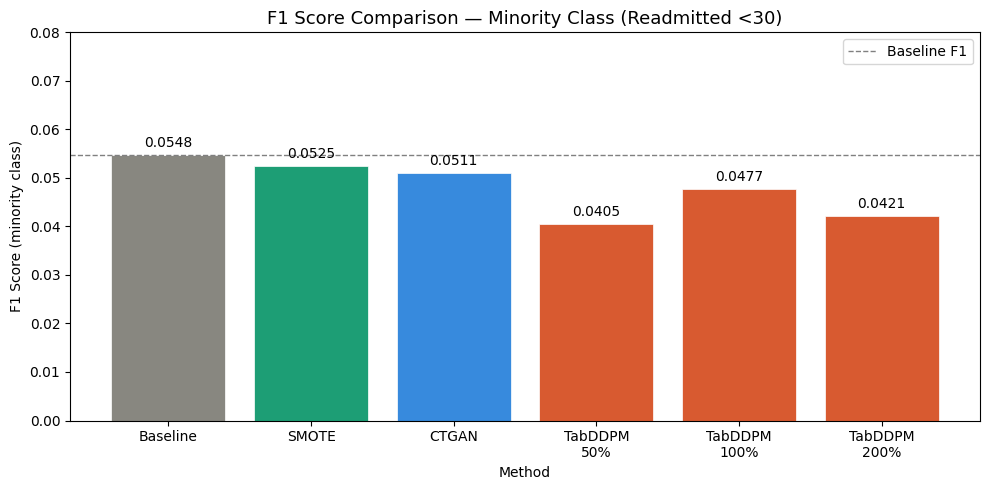

Saved final_comparison.png


In [11]:
# Save TabDDPM metrics and generate final comparison chart

for ratio, res in tabddpm_results.items():
    with open(f'results/metrics/tabddpm_{ratio}_results.json', 'w') as f:
        json.dump(res, f, indent=2)
    print(f"Saved tabddpm_{ratio}_results.json")

# Final comparison bar chart
methods  = ['Baseline', 'SMOTE', 'CTGAN', 'TabDDPM\n50%', 'TabDDPM\n100%', 'TabDDPM\n200%']
f1_scores = [
    f1_base, f1_smote, f1_ctgan,
    tabddpm_results['50pct']['f1_score'],
    tabddpm_results['100pct']['f1_score'],
    tabddpm_results['200pct']['f1_score']
]
colors = ['#888780', '#1D9E75', '#378ADD', '#D85A30', '#D85A30', '#D85A30']

plt.figure(figsize=(10, 5))
bars = plt.bar(methods, f1_scores, color=colors, edgecolor='white', linewidth=0.5)
plt.axhline(y=f1_base, color='gray', linestyle='--', linewidth=1, label='Baseline F1')
for bar, val in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.title('F1 Score Comparison — Minority Class (Readmitted <30)', fontsize=13)
plt.ylabel('F1 Score (minority class)')
plt.xlabel('Method')
plt.ylim(0, 0.08)
plt.legend()
plt.tight_layout()
plt.savefig('results/figures/final_comparison.png', dpi=150)
plt.show()

print("Saved final_comparison.png")

In [12]:
# ── 5-Seed Experiment ──
# Every experiment is repeated 5 times with different random seeds.
# We report mean F1 ± std dev to ensure results are reliable and not lucky.

SEEDS = [42, 7, 13, 21, 99]
results_seeds = {
    'baseline'      : [],
    'smote'         : [],
    'ctgan'         : [],
    'tabddpm_50pct' : [],
    'tabddpm_100pct': [],
    'tabddpm_200pct': []
}

for seed in SEEDS:
    print(f"Running seed {seed}...")

    # Baseline
    clf = XGBClassifier(n_estimators=100, random_state=seed, eval_metric='logloss', use_label_encoder=False)
    clf.fit(X_train, y_train)
    results_seeds['baseline'].append(f1_score(y_test, clf.predict(X_test), pos_label=1))

    # SMOTE
    smote = SMOTE(random_state=seed)
    X_sm, y_sm = smote.fit_resample(X_train, y_train)
    clf = XGBClassifier(n_estimators=100, random_state=seed, eval_metric='logloss', use_label_encoder=False)
    clf.fit(X_sm, y_sm)
    results_seeds['smote'].append(f1_score(y_test, clf.predict(X_test), pos_label=1))

    # CTGAN
    clf = XGBClassifier(n_estimators=100, random_state=seed, eval_metric='logloss', use_label_encoder=False)
    clf.fit(X_train_ctgan, y_train_ctgan)
    results_seeds['ctgan'].append(f1_score(y_test, clf.predict(X_test), pos_label=1))

    # TabDDPM 50%
    X_aug = pd.read_csv('/content/X_train_aug_50pct.csv')
    y_aug = pd.read_csv('/content/y_train_aug_50pct.csv').squeeze()
    clf = XGBClassifier(n_estimators=100, random_state=seed, eval_metric='logloss', use_label_encoder=False)
    clf.fit(X_aug, y_aug)
    results_seeds['tabddpm_50pct'].append(f1_score(y_test, clf.predict(X_test), pos_label=1))

    # TabDDPM 100%
    X_aug = pd.read_csv('/content/X_train_aug_100pct.csv')
    y_aug = pd.read_csv('/content/y_train_aug_100pct.csv').squeeze()
    clf = XGBClassifier(n_estimators=100, random_state=seed, eval_metric='logloss', use_label_encoder=False)
    clf.fit(X_aug, y_aug)
    results_seeds['tabddpm_100pct'].append(f1_score(y_test, clf.predict(X_test), pos_label=1))

    # TabDDPM 200%
    X_aug = pd.read_csv('/content/X_train_aug_200pct.csv')
    y_aug = pd.read_csv('/content/y_train_aug_200pct.csv').squeeze()
    clf = XGBClassifier(n_estimators=100, random_state=seed, eval_metric='logloss', use_label_encoder=False)
    clf.fit(X_aug, y_aug)
    results_seeds['tabddpm_200pct'].append(f1_score(y_test, clf.predict(X_test), pos_label=1))

    print(f"  Seed {seed} done!")

print()
print("=" * 60)
print("  5-SEED RESULTS — Mean F1 ± Std Dev")
print("=" * 60)
for method, scores in results_seeds.items():
    mean = np.mean(scores)
    std  = np.std(scores)
    print(f"  {method:<20} F1: {mean:.4f} ± {std:.4f}")
print("=" * 60)

Running seed 42...
  Seed 42 done!
Running seed 7...
  Seed 7 done!
Running seed 13...
  Seed 13 done!
Running seed 21...
  Seed 21 done!
Running seed 99...
  Seed 99 done!

  5-SEED RESULTS — Mean F1 ± Std Dev
  baseline             F1: 0.0548 ± 0.0000
  smote                F1: 0.0524 ± 0.0052
  ctgan                F1: 0.0511 ± 0.0000
  tabddpm_50pct        F1: 0.0405 ± 0.0000
  tabddpm_100pct       F1: 0.0477 ± 0.0000
  tabddpm_200pct       F1: 0.0421 ± 0.0000


In [13]:
# Save 5-seed experiment results to results folder

seed_summary = {}
for method, scores in results_seeds.items():
    seed_summary[method] = {
        'f1_scores' : [round(s, 4) for s in scores],
        'mean_f1'   : round(np.mean(scores), 4),
        'std_f1'    : round(np.std(scores), 4),
        'seeds'     : SEEDS
    }

with open('results/metrics/5seed_results.json', 'w') as f:
    json.dump(seed_summary, f, indent=2)

print("Saved 5seed_results.json")

Saved 5seed_results.json


In [14]:
# ── Synthetic Only Honesty Test ──
# Train the classifier entirely on synthetic patients, test on real ones.
# If F1 is reasonable, synthetic data genuinely captured real patterns.

# CTGAN synthetic only
X_real_majority = X_train[y_train == 0].copy()
y_real_majority = y_train[y_train == 0].copy()

X_synth_only = pd.concat([X_real_majority, synthetic_patients], ignore_index=True)
y_synth_only = pd.concat([y_real_majority, pd.Series([1] * len(synthetic_patients))], ignore_index=True)

print(f"CTGAN synthetic-only training set: {len(X_synth_only)} rows")
print(f"  Majority (real): {(y_synth_only == 0).sum()}")
print(f"  Minority (CTGAN synthetic): {(y_synth_only == 1).sum()}")

clf = XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False)
clf.fit(X_synth_only, y_synth_only)
y_pred = clf.predict(X_test)
f1_synth_ctgan  = f1_score(y_test, y_pred, pos_label=1)
auc_synth_ctgan = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
print(f"  F1: {f1_synth_ctgan:.4f}  AUC: {auc_synth_ctgan:.4f}")

# TabDDPM synthetic only
X_synth_tabddpm = pd.read_csv('/content/synthetic_100pct.csv')
X_synth_tabddpm = X_synth_tabddpm[X_train.columns]
y_synth_tabddpm = pd.Series([1] * len(X_synth_tabddpm))

X_synth_tabddpm_full = pd.concat([X_real_majority, X_synth_tabddpm], ignore_index=True)
y_synth_tabddpm_full = pd.concat([y_real_majority, y_synth_tabddpm], ignore_index=True)

print(f"\nTabDDPM synthetic-only training set: {len(X_synth_tabddpm_full)} rows")
print(f"  Majority (real): {(y_synth_tabddpm_full == 0).sum()}")
print(f"  Minority (TabDDPM synthetic): {(y_synth_tabddpm_full == 1).sum()}")

clf = XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False)
clf.fit(X_synth_tabddpm_full, y_synth_tabddpm_full)
y_pred = clf.predict(X_test)
f1_synth_tabddpm  = f1_score(y_test, y_pred, pos_label=1)
auc_synth_tabddpm = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
print(f"  F1: {f1_synth_tabddpm:.4f}  AUC: {auc_synth_tabddpm:.4f}")

print()
print("=" * 60)
print("  SYNTHETIC ONLY SUMMARY")
print("=" * 60)
print(f"  {'Method':<25} {'F1':>8} {'AUC':>8}")
print("-" * 60)
print(f"  {'CTGAN synth only':<25} {f1_synth_ctgan:>8.4f} {auc_synth_ctgan:>8.4f}")
print(f"  {'TabDDPM synth only':<25} {f1_synth_tabddpm:>8.4f} {auc_synth_tabddpm:>8.4f}")
print("=" * 60)

CTGAN synthetic-only training set: 79472 rows
  Majority (real): 70421
  Minority (CTGAN synthetic): 9051
  F1: 0.0000  AUC: 0.5786

TabDDPM synthetic-only training set: 79472 rows
  Majority (real): 70421
  Minority (TabDDPM synthetic): 9051
  F1: 0.0000  AUC: 0.5859

  SYNTHETIC ONLY SUMMARY
  Method                          F1      AUC
------------------------------------------------------------
  CTGAN synth only            0.0000   0.5786
  TabDDPM synth only          0.0000   0.5859


In [15]:
# Save synthetic only honesty test results to results folder

synth_only_metrics = {
    'ctgan_synthetic_only': {
        'f1_score': round(f1_synth_ctgan, 4),
        'roc_auc' : round(auc_synth_ctgan, 4),
        'note'    : 'Trained on CTGAN synthetic data only, tested on real patients'
    },
    'tabddpm_synthetic_only': {
        'f1_score': round(f1_synth_tabddpm, 4),
        'roc_auc' : round(auc_synth_tabddpm, 4),
        'note'    : 'Trained on TabDDPM synthetic minority + real majority, tested on real patients'
    }
}

with open('results/metrics/synthetic_only_results.json', 'w') as f:
    json.dump(synth_only_metrics, f, indent=2)

print("Saved synthetic_only_results.json")
print()
print("=" * 60)
print("  Results saved to results/metrics/")
print("  Figures saved to results/figures/")
print("=" * 60)

Saved synthetic_only_results.json

  Results saved to results/metrics/
  Figures saved to results/figures/


In [18]:
# Jensen-Shannon Divergence — measures how similar real vs synthetic distributions are
# Closer to 0 = more similar = better quality synthetic data
from scipy.spatial.distance import jensenshannon
import numpy as np
import pandas as pd

# Load real minority patients and TabDDPM synthetic patients
real_minority = X_train[y_train == 1].copy()
synthetic = pd.read_csv('/content/synthetic_100pct.csv')
synthetic = synthetic[X_train.columns]

print("Jensen-Shannon Divergence — Real vs TabDDPM Synthetic")
print("(0 = identical distributions, 1 = completely different)")
print("=" * 55)

js_scores = {}
for col in real_minority.columns:
    # Get value distributions for each column
    real_vals = real_minority[col].dropna()
    synth_vals = synthetic[col].dropna()

    # Create shared bins for comparison
    combined_min = min(real_vals.min(), synth_vals.min())
    combined_max = max(real_vals.max(), synth_vals.max())
    bins = np.linspace(combined_min, combined_max, 20)

    real_hist,  _ = np.histogram(real_vals,  bins=bins, density=True)
    synth_hist, _ = np.histogram(synth_vals, bins=bins, density=True)

    # Add small epsilon to avoid division by zero
    real_hist  = real_hist  + 1e-10
    synth_hist = synth_hist + 1e-10

    js = jensenshannon(real_hist, synth_hist)
    js_scores[col] = round(js, 4)

# Print top 10 best and worst columns
sorted_scores = sorted(js_scores.items(), key=lambda x: x[1])
print(f"\n  Mean JS Divergence (all columns): {np.mean(list(js_scores.values())):.4f}")
print(f"\n  5 most similar columns (lowest JS):")
for col, score in sorted_scores[:5]:
    print(f"    {col:<35} {score:.4f}")
print(f"\n  5 least similar columns (highest JS):")
for col, score in sorted_scores[-5:]:
    print(f"    {col:<35} {score:.4f}")

Jensen-Shannon Divergence — Real vs TabDDPM Synthetic
(0 = identical distributions, 1 = completely different)

  Mean JS Divergence (all columns): nan

  5 most similar columns (lowest JS):
    diabetesMed                         0.0007
    chlorpropamide                      0.0018
    tolazamide                          0.0024
    change                              0.0027
    miglitol                            0.0031

  5 least similar columns (highest JS):
    troglitazone                        nan
    glipizide-metformin                 nan
    glimepiride-pioglitazone            nan
    metformin-rosiglitazone             nan
    metformin-pioglitazone              nan


In [19]:
# Fixed Jensen-Shannon Divergence — handles zero variance columns
from scipy.spatial.distance import jensenshannon
import numpy as np

print("Jensen-Shannon Divergence — Real vs TabDDPM Synthetic")
print("(0 = identical distributions, 1 = completely different)")
print("=" * 55)

js_scores = {}
skipped = []

for col in real_minority.columns:
    real_vals  = real_minority[col].dropna()
    synth_vals = synthetic[col].dropna()

    # Skip columns with no variance in either dataset
    if real_vals.std() == 0 or synth_vals.std() == 0:
        skipped.append(col)
        continue

    combined_min = min(real_vals.min(), synth_vals.min())
    combined_max = max(real_vals.max(), synth_vals.max())

    if combined_min == combined_max:
        skipped.append(col)
        continue

    bins = np.linspace(combined_min, combined_max, 20)
    real_hist,  _ = np.histogram(real_vals,  bins=bins, density=True)
    synth_hist, _ = np.histogram(synth_vals, bins=bins, density=True)

    real_hist  = real_hist  + 1e-10
    synth_hist = synth_hist + 1e-10

    js = jensenshannon(real_hist, synth_hist)
    js_scores[col] = round(js, 4)

sorted_scores = sorted(js_scores.items(), key=lambda x: x[1])
mean_js = np.mean(list(js_scores.values()))

print(f"\n  Columns evaluated : {len(js_scores)}")
print(f"  Columns skipped   : {len(skipped)} (zero variance)")
print(f"\n  Mean JS Divergence: {mean_js:.4f}")
print(f"\n  5 most similar columns:")
for col, score in sorted_scores[:5]:
    print(f"    {col:<35} {score:.4f}")
print(f"\n  5 least similar columns:")
for col, score in sorted_scores[-5:]:
    print(f"    {col:<35} {score:.4f}")

Jensen-Shannon Divergence — Real vs TabDDPM Synthetic
(0 = identical distributions, 1 = completely different)

  Columns evaluated : 35
  Columns skipped   : 7 (zero variance)

  Mean JS Divergence: 0.0610

  5 most similar columns:
    diabetesMed                         0.0007
    chlorpropamide                      0.0018
    tolazamide                          0.0024
    change                              0.0027
    miglitol                            0.0031

  5 least similar columns:
    num_medications                     0.1396
    number_diagnoses                    0.1994
    time_in_hospital                    0.3407
    num_procedures                      0.4041
    age                                 0.4789


  THRESHOLD TUNING RESULTS — F1 Score by Threshold
  Threshold     Baseline          SMOTE             CTGAN             TabDDPM 100%    
-----------------------------------------------------------------
  0.05          0.2269            0.2200            0.2243            0.2260          
  0.10          0.2653            0.2516            0.2625            0.2658          
  0.15          0.2686            0.2712            0.2723            0.2704          
  0.20          0.2451            0.2568            0.2490            0.2515          
  0.25          0.2040            0.2200            0.2087            0.2070          
  0.30          0.1601            0.1779            0.1663            0.1744          
  0.35          0.1249            0.1399            0.1164            0.1250          
  0.40          0.0929            0.1035            0.0911            0.0924          
  0.45          0.0733            0.0732            0.0693            0.0725          
  0.50       

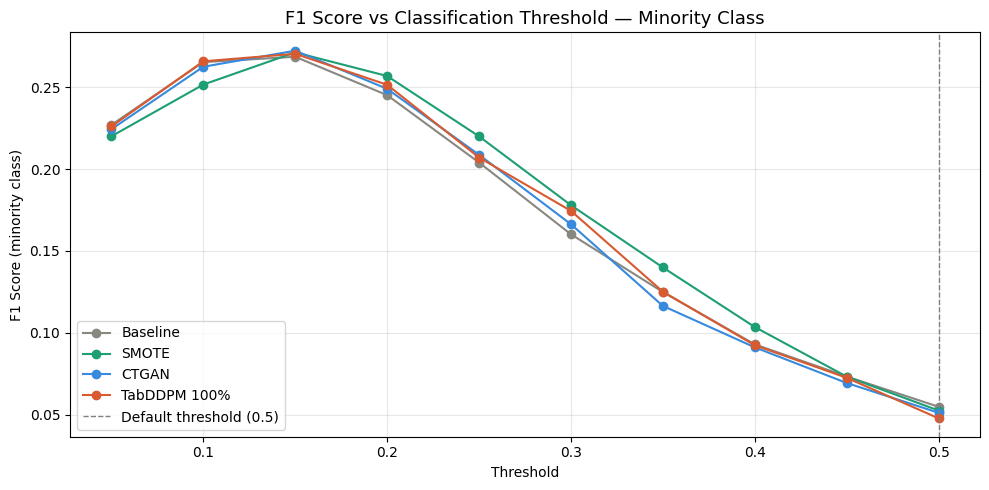

Saved results/figures/threshold_tuning.png


In [16]:
# ── Threshold Tuning Experiment ──
# Default XGBoost threshold is 0.5. Since only 11% of patients are readmitted,
# lowering the threshold flags more patients as readmitted, potentially improving F1.
# We test thresholds from 0.1 to 0.5 on each method and find the optimal cutoff.

from sklearn.metrics import f1_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

thresholds = np.arange(0.05, 0.55, 0.05)

# Store results for each method
threshold_results = {}

# --- Baseline ---
y_proba_base = baseline_model.predict_proba(X_test)[:, 1]
f1_by_threshold = []
for t in thresholds:
    y_pred_t = (y_proba_base >= t).astype(int)
    f1_by_threshold.append(f1_score(y_test, y_pred_t, pos_label=1))
threshold_results['Baseline'] = f1_by_threshold

# --- SMOTE ---
y_proba_smote = smote_model.predict_proba(X_test)[:, 1]
f1_by_threshold = []
for t in thresholds:
    y_pred_t = (y_proba_smote >= t).astype(int)
    f1_by_threshold.append(f1_score(y_test, y_pred_t, pos_label=1))
threshold_results['SMOTE'] = f1_by_threshold

# --- CTGAN ---
y_proba_ctgan = ctgan_clf.predict_proba(X_test)[:, 1]
f1_by_threshold = []
for t in thresholds:
    y_pred_t = (y_proba_ctgan >= t).astype(int)
    f1_by_threshold.append(f1_score(y_test, y_pred_t, pos_label=1))
threshold_results['CTGAN'] = f1_by_threshold

# --- TabDDPM 100% (best performing) ---
X_aug_100 = pd.read_csv('/content/X_train_aug_100pct.csv')
y_aug_100 = pd.read_csv('/content/y_train_aug_100pct.csv').squeeze()
clf_100 = XGBClassifier(n_estimators=100, random_state=RANDOM_STATE,
                         eval_metric='logloss', use_label_encoder=False)
clf_100.fit(X_aug_100, y_aug_100)
y_proba_tab100 = clf_100.predict_proba(X_test)[:, 1]
f1_by_threshold = []
for t in thresholds:
    y_pred_t = (y_proba_tab100 >= t).astype(int)
    f1_by_threshold.append(f1_score(y_test, y_pred_t, pos_label=1))
threshold_results['TabDDPM 100%'] = f1_by_threshold

# Print results table
print("=" * 65)
print("  THRESHOLD TUNING RESULTS — F1 Score by Threshold")
print("=" * 65)
print(f"  {'Threshold':<12}", end="")
for method in threshold_results:
    print(f"  {method:<16}", end="")
print()
print("-" * 65)
for i, t in enumerate(thresholds):
    print(f"  {t:<12.2f}", end="")
    for method in threshold_results:
        print(f"  {threshold_results[method][i]:<16.4f}", end="")
    print()
print("=" * 65)

# Print best threshold per method
print("\n  Best threshold per method:")
for method, scores in threshold_results.items():
    best_idx = np.argmax(scores)
    print(f"  {method:<20} Best threshold: {thresholds[best_idx]:.2f}  F1: {scores[best_idx]:.4f}")

# Plot
plt.figure(figsize=(10, 5))
colors = ['#888780', '#1D9E75', '#378ADD', '#D85A30']
for (method, scores), color in zip(threshold_results.items(), colors):
    plt.plot(thresholds, scores, marker='o', label=method, color=color)
plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=1, label='Default threshold (0.5)')
plt.title('F1 Score vs Classification Threshold — Minority Class', fontsize=13)
plt.xlabel('Threshold')
plt.ylabel('F1 Score (minority class)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/threshold_tuning.png', dpi=150)
plt.show()
print("Saved results/figures/threshold_tuning.png")

In [17]:
# Save threshold tuning results
import json
import numpy as np

threshold_metrics = {}
for method, scores in threshold_results.items():
    best_idx = int(np.argmax(scores))
    threshold_metrics[method] = {
        'best_threshold': round(float(thresholds[best_idx]), 2),
        'best_f1'       : round(float(scores[best_idx]), 4),
        'default_f1'    : round(float(scores[-1]), 4),
        'improvement'   : round(float(scores[best_idx]) - float(scores[-1]), 4),
        'all_thresholds': [round(float(t), 2) for t in thresholds],
        'all_f1_scores' : [round(float(s), 4) for s in scores]
    }

with open('results/metrics/threshold_tuning_results.json', 'w') as f:
    json.dump(threshold_metrics, f, indent=2)

print("Saved threshold_tuning_results.json")
print()
print("Summary of improvement:")
for method, data in threshold_metrics.items():
    print(f"  {method:<20} {data['default_f1']:.4f} → {data['best_f1']:.4f}  (+{data['improvement']:.4f})")

Saved threshold_tuning_results.json

Summary of improvement:
  Baseline             0.0548 → 0.2686  (+0.2138)
  SMOTE                0.0525 → 0.2712  (+0.2188)
  CTGAN                0.0511 → 0.2723  (+0.2212)
  TabDDPM 100%         0.0477 → 0.2704  (+0.2226)
